## Exercise 7

### Part 1

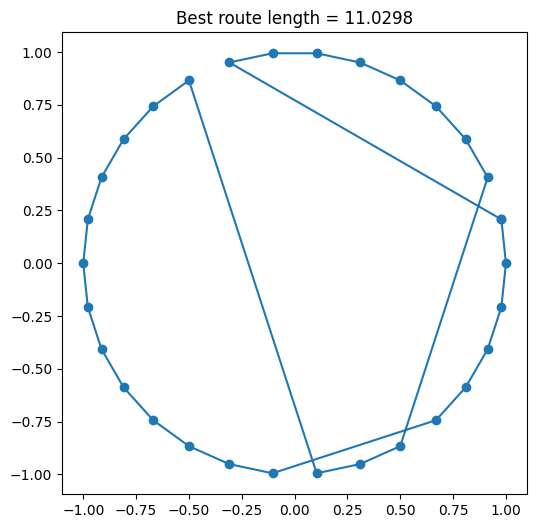

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate points on a circle
n = 30

theta = np.linspace(0, 2*np.pi, n, endpoint=False)

points = np.column_stack([
    np.cos(theta),
    np.sin(theta)
])

# Cost function (length of route)
def route_length(route, points):
    total = 0.0

    for i in range(len(route)):
        current_city = route[i]
        next_city = route[(i + 1) % len(route)]

        total += np.linalg.norm(
            points[current_city] - points[next_city]
        )

    return total


# Simulated annealing
num_iterations = 50000

# Initial random route
current_route = np.random.permutation(n)

current_cost = route_length(current_route, points)

best_route = current_route.copy()
best_cost = current_cost

for k in range(num_iterations):

    # Cooling scheme
    T = 1.0 / np.sqrt(1 + k)

    # Generate proposal by swapping two of the cities
    proposal = current_route.copy()

    i, j = np.random.choice(n, 2, replace=False)

    proposal[i], proposal[j] = proposal[j], proposal[i]

    proposal_cost = route_length(proposal, points)

    delta = proposal_cost - current_cost

    # Accept if better
    if delta < 0:
        current_route = proposal
        current_cost = proposal_cost

    # Accept worse solution probabilistically
    else:
        if np.random.rand() < np.exp(-delta / T):
            current_route = proposal
            current_cost = proposal_cost

    # Store the best solution found
    if current_cost < best_cost:
        best_cost = current_cost
        best_route = current_route.copy()


# Plot result
ordered_points = points[best_route]

x = np.append(ordered_points[:, 0], ordered_points[0, 0])
y = np.append(ordered_points[:, 1], ordered_points[0, 1])

plt.figure(figsize=(6, 6))
plt.plot(x, y, "-o")
plt.title(f"Best route length = {best_cost:.4f}")
plt.axis("equal")
plt.show()

### Part 2

In [ ]:
import pandas as pd

# Load matrix and convert to numpy array
df = pd.read_csv("C:/Users/Lenovo/OneDrive - Danmarks Tekniske Universitet/Dokumenter/DTU/8. semester/Stochastic Simulation/cost.csv", header=None)
cost_matrix = df.values
n = cost_matrix.shape[0]

# Route cost function
def route_cost(route, cost_matrix):
    total = 0

    for i in range(len(route)):
        a = route[i]
        b = route[(i + 1) % len(route)]

        total += cost_matrix[a, b]

    return total

# Proposal function using the swap move
def propose_swap(route):
    new_route = route.copy()
    i, j = np.random.choice(len(route), 2, replace=False)
    new_route[i], new_route[j] = new_route[j], new_route[i]
    return new_route

# Simulated annealing
def simulated_annealing(cost_matrix, max_iter=50000):

    n = len(cost_matrix)

    # initial solution
    current_route = np.random.permutation(n)
    current_cost = route_cost(current_route, cost_matrix)

    best_route = current_route.copy()
    best_cost = current_cost

    for k in range(max_iter):

        # Cooling scheme
        T = 1.0 / np.sqrt(1 + k)

        # Propose new solution
        new_route = propose_swap(current_route)
        new_cost = route_cost(new_route, cost_matrix)

        delta = new_cost - current_cost

        # Accept better solution
        if delta < 0:
            current_route = new_route
            current_cost = new_cost

        # Accept worse solution probabilistically
        else:
            if np.random.rand() < np.exp(-delta / T):
                current_route = new_route
                current_cost = new_cost

        # update best solution
        if current_cost < best_cost:
            best_cost = current_cost
            best_route = current_route.copy()

    return best_route, best_cost

# Run algorithm
best_route, best_cost = simulated_annealing(cost_matrix)

print("Best route:", best_route)
print("Best cost:", best_cost)

Best route: [ 2 12  3  0  5 11  4  7 15  9 18 14  1  8 13  6 17 16 10 19]
Best cost: 817


In [8]:
# Experiment with different cooling schedules and proposal mechanisms

# Proposal functions
def propose_swap(route):
    r = route.copy()
    i, j = np.random.choice(len(route), 2, replace=False)
    r[i], r[j] = r[j], r[i]
    return r

def propose_reverse(route):
    r = route.copy()
    i, j = sorted(np.random.choice(len(route), 2, replace=False))
    r[i:j] = r[i:j][::-1]
    return r


# Coolings schemes
def cooling_sqrt(k):
    return 1 / np.sqrt(1 + k)

def cooling_log(k):
    return 1 / np.log(2 + k)


# General simulated annealing function 
def simulated_annealing(cost_matrix, propose, cooling, max_iter=30000):

    n = len(cost_matrix)

    current = np.random.permutation(n)
    current_cost = route_cost(current, cost_matrix)

    best = current.copy()
    best_cost = current_cost

    for k in range(max_iter):

        T = cooling(k)

        new = propose(current)
        new_cost = route_cost(new, cost_matrix)

        delta = new_cost - current_cost

        if delta < 0 or np.random.rand() < np.exp(-delta / T):
            current = new
            current_cost = new_cost

        if current_cost < best_cost:
            best = current.copy()
            best_cost = current_cost

    return best_cost


# Run experiments
proposals = {
    "swap": propose_swap,
    "reverse": propose_reverse
}

coolings = {
    "sqrt": cooling_sqrt,
    "log": cooling_log,
}

results = {}

for p_name, p_func in proposals.items():
    for c_name, c_func in coolings.items():

        best_cost = simulated_annealing(
            cost_matrix,
            propose=p_func,
            cooling=c_func
        )

        results[(p_name, c_name)] = best_cost


for key, value in results.items():
    print(f"{key}: {value:.2f}")

('swap', 'sqrt'): 1255.00
('swap', 'log'): 1559.00
('reverse', 'sqrt'): 825.00
('reverse', 'log'): 810.00
